We are implementing the paper automatic visual circuit discovery for two layers MLP for MNIST and colored MNIST and try to check the graphs are isomorphic or not.

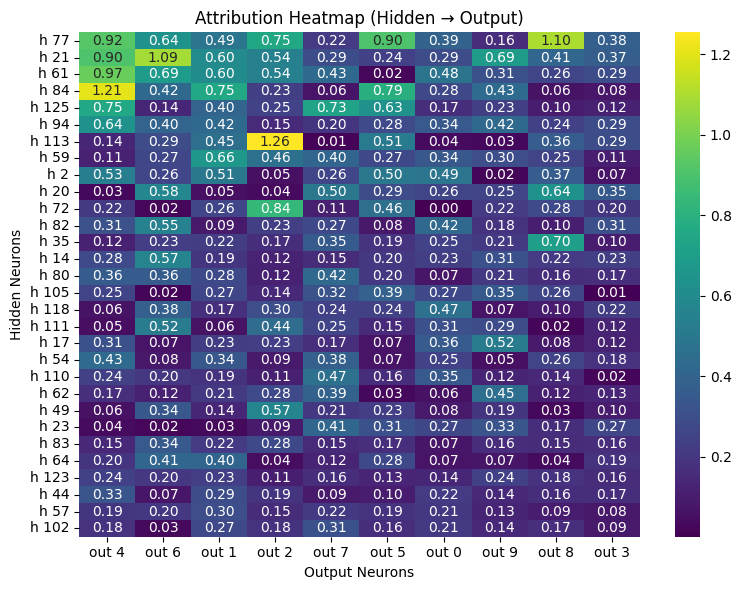

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Set seed
torch.manual_seed(42)

# ========== 1. Model ==========
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        self.l1 = F.relu(self.fc1(x))   # Hidden layer activations
        out = self.fc2(self.l1)
        return out

# ========== 2. Dataset ==========
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ========== 3. Training ==========
def train(model, loader, epochs=1):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        for x, y in loader:
            out = model(x)
            loss = loss_fn(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

model = MLP()
train(model, train_loader, epochs=1)
model.eval()

# ========== 4. Attribution Matrix ==========
def attribution_matrix(model, x):
    x = x.unsqueeze(0).requires_grad_(True)
    out = model(x)  # forward pass
    activations = model.l1.detach()
    attributions = torch.zeros((128, 10))  # hidden_size x num_classes

    for n in range(10):
        model.zero_grad()
        output = model(x)
        grad_output = torch.zeros_like(output)
        grad_output[0, n] = 1.0
        activ = model.l1
        grads = torch.autograd.grad(outputs=output, inputs=activ, grad_outputs=grad_output,
                                    retain_graph=True)[0][0]
        attributions[:, n] = (activ[0] * grads).abs()

    return attributions

# ========== 5. Circuit Discovery ==========
def build_circuit(attr_matrix, k1=10, k2=5):
    # Top-k hidden neurons by total attribution
    top_hidden = torch.topk(attr_matrix.sum(dim=1), k1).indices
    # Top-k output neurons most influenced by selected hidden
    top_output = torch.topk(attr_matrix[top_hidden].sum(dim=0), k2).indices
    return top_hidden, top_output

# ========== 6. Visualize Circuit ==========
def visualize_circuit(attr_matrix, top_hidden, top_output):
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    data = attr_matrix[top_hidden][:, top_output].detach().numpy()
    sns.heatmap(data, annot=True, fmt=".2f", cmap="viridis",
                xticklabels=[f"out {i.item()}" for i in top_output],
                yticklabels=[f"h {i.item()}" for i in top_hidden])
    plt.title("Attribution Heatmap (Hidden → Output)")
    plt.xlabel("Output Neurons")
    plt.ylabel("Hidden Neurons")
    plt.tight_layout()
    plt.show()

# ========== 7. Run Circuit Discovery ==========
x_sample, _ = train_dataset[0]
attr = attribution_matrix(model, x_sample)
top_hidden, top_output = build_circuit(attr, k1=30, k2=10)
visualize_circuit(attr, top_hidden, top_output)


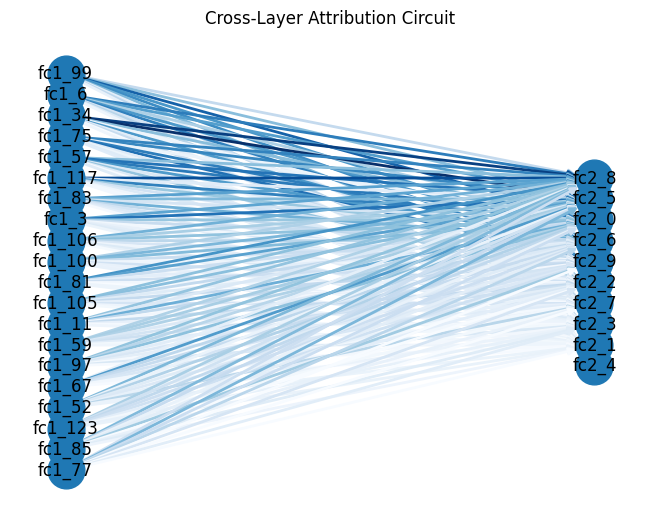

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

# Set seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# Define a simple 2-layer MLP for MNIST
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)
        #self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        a1 = F.relu(self.fc1(x))
        #a2 = F.relu(self.fc2(a1))
        out = self.fc2(a1)
        return out, a1

model = MLP()

# Pick a single batch to work with
images, labels = next(iter(trainloader))
images = images[:32]  # use a small batch for attribution calculation

# Forward pass and get activations
outputs, a1 = model(images)

# Compute Cross-Layer Attribution between fc1 and fc2
def attribution_matrix(model, inputs, layer1, layer2):
    model.eval()
    inputs = inputs.view(inputs.size(0), -1)
    a1 = F.relu(model.fc1(inputs))
    a2 = F.relu(model.fc2(a1))
    attr = torch.zeros(a1.size(1), a2.size(1))
    for i in range(a2.size(1)):
        grads = torch.autograd.grad(a2[:, i].sum(), a1, retain_graph=True)[0]
        attr[:, i] = (a1 * grads).abs().mean(dim=0)
    return attr.detach()

attr_fc1_fc2 = attribution_matrix(model, images, model.fc1, model.fc2)

# Select top-k neurons per layer to build initial circuit
def build_circuit(attr_matrix, k1=20, k2=10):
    circuit = {}
    top_k1 = torch.topk(attr_matrix.sum(dim=1), k=k1).indices.tolist()
    circuit['fc1'] = top_k1
    sub_attr = attr_matrix[top_k1, :]
    top_k2 = torch.topk(sub_attr.sum(dim=0), k=k2).indices.tolist()
    circuit['fc2'] = top_k2
    return circuit

circuit = build_circuit(attr_fc1_fc2)

# Visualize the circuit as a bipartite graph
def visualize_circuit(attr_matrix, circuit, layer1_name="fc1", layer2_name="fc2"):
    G = nx.DiGraph()
    for i in circuit[layer1_name]:
        G.add_node(f"{layer1_name}_{i}", layer=0)
    for j in circuit[layer2_name]:
        G.add_node(f"{layer2_name}_{j}", layer=1)
    for i in circuit[layer1_name]:
        for j in circuit[layer2_name]:
            weight = attr_matrix[i, j].item()
            if weight > 0:
                G.add_edge(f"{layer1_name}_{i}", f"{layer2_name}_{j}", weight=weight)
    
    pos = nx.multipartite_layout(G, subset_key="layer")
    weights = [G[u][v]['weight'] for u,v in G.edges]
    nx.draw(G, pos, with_labels=True, node_size=700, edge_color=weights, edge_cmap=plt.cm.Blues, width=2)
    plt.title("Cross-Layer Attribution Circuit")
    plt.show()

visualize_circuit(attr_fc1_fc2, circuit)




True label: 5
Original prediction: 5


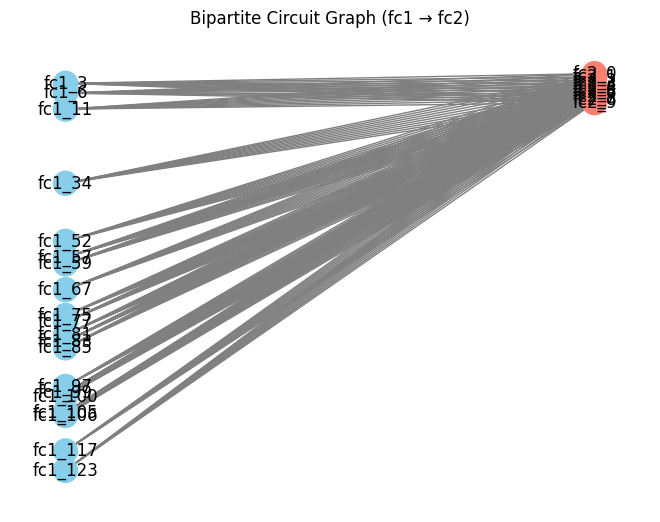

Prediction after Edge Pruning: 5
Prediction after Circuit Pruning: 0


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from collections import defaultdict

# ---- MLP model ----
class MLP(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        self.a1 = F.relu(self.fc1(x))
        self.a2 = self.fc2(self.a1)
        return self.a2

# ---- Dataset ----
def get_data():
    transform = transforms.ToTensor()
    test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)
    return next(iter(test_loader))

# ---- Circuit (dummy: top 5 neurons from each layer) ----
def get_dummy_circuit(model):
    return {
        'fc1': [99, 6, 34, 75, 57, 117, 83, 3, 106, 100, 81, 105, 11, 59, 97, 67, 52, 123, 85, 77],
        'fc2': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    }

# ---- Visualize bipartite circuit ----
def visualize_circuit(circuit, layer_sizes=(128, 10)):
    B = nx.DiGraph()
    fc1_ids = [f"fc1_{i}" for i in range(layer_sizes[0])]
    fc2_ids = [f"fc2_{j}" for j in range(layer_sizes[1])]

    for i in circuit['fc1']:
        B.add_node(f"fc1_{i}", layer='fc1', color='skyblue')
    for j in circuit['fc2']:
        B.add_node(f"fc2_{j}", layer='fc2', color='salmon')

    for i in circuit['fc1']:
        for j in circuit['fc2']:
            B.add_edge(f"fc1_{i}", f"fc2_{j}")

    pos = {}
    for idx, node in enumerate(fc1_ids):
        pos[node] = (0, -idx)
    for idx, node in enumerate(fc2_ids):
        pos[node] = (1, -idx)

    node_colors = [B.nodes[n].get('color', 'lightgrey') for n in B.nodes]
    nx.draw(B, pos, with_labels=True, node_color=node_colors, edge_color='gray', arrows=False)
    plt.title("Bipartite Circuit Graph (fc1 → fc2)")
    plt.axis('off')
    plt.show()

# ---- Edge Pruning ----
def edge_prune(model, x, circuit):
    x_flat = x.view(1, -1)
    clean = model(x)

    a1 = F.relu(model.fc1(x_flat)).detach().clone()
    for i in circuit['fc1']:
        a1[0, i] = 0  # ablate circuit neurons

    a2 = model.fc2(a1)
    for j in range(a2.shape[1]):
        if j not in circuit['fc2']:
            a2[0, j] = clean[0, j]  # restore non-circuit outputs

    return a2

# ---- Circuit Pruning ----
def circuit_prune(model, x, circuit):
    x_flat = x.view(1, -1)
    clean_a1 = F.relu(model.fc1(x_flat)).detach()
    clean_a2 = model.fc2(clean_a1).detach()

    a1 = F.relu(model.fc1(x_flat)).detach().clone()
    for i in range(a1.shape[1]):
        if i in circuit['fc1']:
            a1[0, i] = 0

    a2 = model.fc2(a1)
    for j in range(a2.shape[1]):
        if j in circuit['fc2']:
            a2[0, j] = 0
        else:
            a2[0, j] = clean_a2[0, j]

    return a2

# ---- Demo ----
def demo():
    torch.manual_seed(42)
    model = MLP()
    model.eval()

    x, y = get_data()
    print(f"\nTrue label: {y.item()}")

    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax().item()
    print(f"Original prediction: {pred}")

    circuit = get_dummy_circuit(model)
    visualize_circuit(circuit)

    logits_edge = edge_prune(model, x, circuit)
    pred_edge = logits_edge.argmax().item()
    print(f"Prediction after Edge Pruning: {pred_edge}")

    logits_circuit = circuit_prune(model, x, circuit)
    pred_circuit = logits_circuit.argmax().item()
    print(f"Prediction after Circuit Pruning: {pred_circuit}")

if __name__ == "__main__":
    demo()

